# Cliques

This notebook investigates how many radio cliques there are. A _radio clique_ is a collection of radio islands that transitively appear in the same subjects &mdash; in other words, radio islands that will have more annotations than expected by the experimental design, and perhaps more complicated merging logic. Two cliques will, with very unusual but physically possible exceptions, never both contain radio components of the same physical radio galaxy unless they are the same clique.

When aggregating annotations, we should really be looking at cliques rather than subjects, as without the entire clique we are missing information. That's why we have to merge, eventually. This also results in an artifically lowered signal/consensus for high-confidence sources. To know what aggregation methods are viable, we need to know how large cliques are.

In [1]:
import itertools
import random

import disjoint_set
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

import rgz.classifications
import rgz.subjects

In [2]:
classifications_path = '../full_data/proc/classifications.json'

In [3]:
classifications = list(rgz.classifications.read(classifications_path))

Rather than complicated distance logic, we'll base the cliques on what people _actually classified_. If someone annotated two FIRST objects, they're in the same clique.

In [4]:
cliques = disjoint_set.DisjointSet()

In [5]:
for classification in tqdm(classifications):
    islands = []
    for _, radio_source in classification.coord_matches:
        islands.extend(radio_source)
    for island_a, island_b in itertools.product(islands, repeat=2):
        cliques.union(island_a, island_b)

  0%|          | 0/2232806 [00:00<?, ?it/s]

In [6]:
lengths = []
for s in cliques.itersets():
    lengths.append(len(s))

In [7]:
len(lengths), len(cliques)

(122322, 245688)

Text(0, 0.5, 'Count')

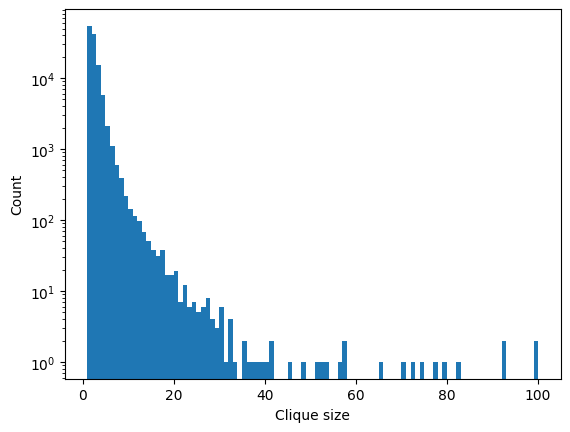

In [8]:
bins = np.linspace(1, 100, 100)
plt.hist(lengths, bins=bins)
plt.yscale('log')
plt.xlabel('Clique size')
plt.ylabel('Count')

It's really weird to have very large numbers here. What kind of objects are in the big cliques?

In [9]:
lengths = {}
for s in cliques.itersets():
    lengths[list(s)[0]] = len(s)

In [10]:
by_length = sorted(lengths.items(), key=lambda a: a[1])
by_length[:-10:-1]

[('NOFIRST_J071937.0329933+230931.79727752', 221),
 ('NOFIRST_J221232.94046943+142230.87998105', 138),
 ('NOFIRST_J001150.01724438+124232.0202309', 127),
 ('NOFIRST_J205101.77380368+024240.92291123', 116),
 ('NOFIRST_J150849.78706417+585848.89864801', 116),
 ('NOFIRST_J213032.3750916+050151.87939291', 103),
 ('NOFIRST_J224159.10218807+095142.70833765', 100),
 ('NOFIRST_J223007.58722768+035131.30418776', 99),
 ('NOFIRST_J093858.71028792+590154.73302625', 92)]

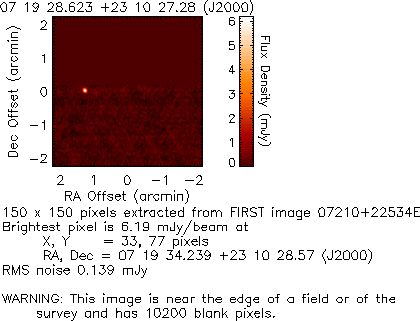
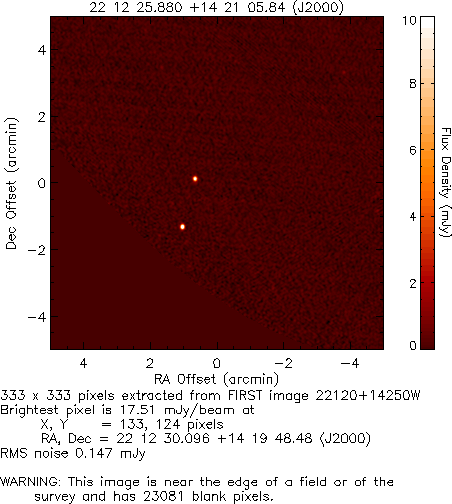

These seem to be edge artefacts, so we can probably ignore them.

BTW, there's an optimisation here - if two FIRST objects _always_ appear in the same partition, then we can call them the same thing for all practical purposes. This is relevant because we basically split up islands into components in our pipeline.

In [11]:
dict(classifications[0].coord_matches)

{'13 45 41.37824287 +23 22 50.96493465': RadioSource(('FIRST_J134540.6+232256', 'FIRST_J134541.6+232252')),
 'NOSOURCE': RadioSource(('FIRST_J134538.4+232247',))}

In [12]:
from rgz import alt_aggregation

Pick an arbitrary clique.

In [13]:
clique_root = 'FIRST_J165754.1+232207'  # The first name with 5 components.

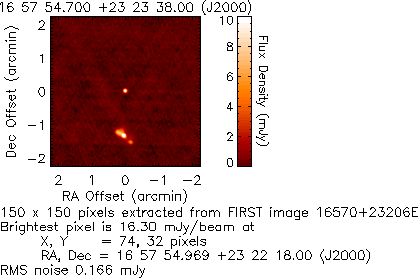

In [14]:
clique = None
for i in cliques.itersets():
    if clique_root in i:
        clique = i
        break

In [15]:
def get_classifications_in_clique(clique: set[str]) -> list[...]:
    classifications_in_clique = []
    for c in classifications:
        found = False
        for _, rs in c.coord_matches:
            for r in rs:
                if r in clique:
                    classifications_in_clique.append(c)
                    found = True
                    break
            if found:
                break
    return classifications_in_clique

In [16]:
classifications_in_clique = get_classifications_in_clique(clique)
len(classifications_in_clique)

59

In [17]:
import importlib
importlib.reload(alt_aggregation)

<module 'rgz.alt_aggregation' from '/home/matthew/native-repos/rgzdr2/rgz/alt_aggregation.py'>

In [18]:
alt_aggregation.aggregate_subset_dp(classifications_in_clique)

/home/matthew/native-repos/rgzdr2/rgz/alt_aggregation.py:101: RuntimeWarning: divide by zero encountered in divide
  weights = np.where(~p_one, p_same_partition / (1 - p_same_partition), VERY_BIG)


Aggregation(aggregation=frozenset({frozenset({'FIRST_J165754.7+232338'}), frozenset({'NOFIRST_J165754.6666501+232332.16033738'}), frozenset({'FIRST_J165755.4+232223', 'FIRST_J165754.9+232217', 'FIRST_J165754.1+232207'})}), scores={frozenset({'FIRST_J165754.7+232338'}): np.float64(0.8881263757607147), frozenset({'NOFIRST_J165754.6666501+232332.16033738'}): np.float64(0.5559368121196426), frozenset({'FIRST_J165755.4+232223', 'FIRST_J165754.9+232217', 'FIRST_J165754.1+232207'}): np.float64(0.44406318788035737)}, probability=np.float64(0.44406318788035737))

In [19]:
' '.join(sorted(clique))

'FIRST_J165754.1+232207 FIRST_J165754.7+232338 FIRST_J165754.9+232217 FIRST_J165755.4+232223 NOFIRST_J165754.6666501+232332.16033738'

In [20]:
alt_aggregation.aggregate_subset_dp(classifications_in_clique)

Aggregation(aggregation=frozenset({frozenset({'FIRST_J165754.7+232338'}), frozenset({'NOFIRST_J165754.6666501+232332.16033738'}), frozenset({'FIRST_J165755.4+232223', 'FIRST_J165754.9+232217', 'FIRST_J165754.1+232207'})}), scores={frozenset({'FIRST_J165754.7+232338'}): np.float64(0.8881263757607147), frozenset({'NOFIRST_J165754.6666501+232332.16033738'}): np.float64(0.5559368121196426), frozenset({'FIRST_J165755.4+232223', 'FIRST_J165754.9+232217', 'FIRST_J165754.1+232207'}): np.float64(0.44406318788035737)}, probability=np.float64(0.44406318788035737))

Try another.

In [21]:
all_cliques = sorted(cliques.itersets())

In [25]:
this_clique = None
while not this_clique or len(this_clique) < 5:
    this_clique = random.choice(all_cliques)
    this_clique = [i for i in this_clique if not i.startswith('NO')]
' '.join(this_clique)

'FIRST_J112356.5+505331 FIRST_J112406.8+505304 FIRST_J112355.4+505403 FIRST_J112358.5+505427 FIRST_J112355.9+505413'

In [30]:
get_classifications_in_clique(this_clique)

[Classification(cid='53a190747f73ee08a8000088', zid='ARG0001n3v', coord_matches=[('13 52 12.55812824 +31 27 39.14521383', RadioSource(('FIRST_J135212.4+312736', 'FIRST_J135212.7+312738', 'FIRST_J135212.7+312752'))), ('13 52 15.80714695 +31 27 27.56640891', RadioSource(('NOFIRST_J135215.77550552+312727.69749874',))), ('13 52 15.83583376 +31 27 07.6123034', RadioSource(('FIRST_J135215.1+312708', 'FIRST_J135215.9+312710'))), ('13 52 16.89350943 +31 26 50.16743834', RadioSource(('FIRST_J135216.8+312651', 'FIRST_J135217.8+312646'))), ('13 52 17.36000295 +31 26 59.06525177', RadioSource(('NOFIRST_J135217.31446531+312659.95847218',)))], username='planetari7', notes=['MULTISOURCE']),
 Classification(cid='53b27a9e037b3047a1000252', zid='ARG0001n3v', coord_matches=[('13 52 12.4283954 +31 27 47.88806113', RadioSource(('FIRST_J135212.4+312736', 'FIRST_J135212.7+312738', 'FIRST_J135212.7+312752'))), ('13 52 14.64141857 +31 27 02.38443089', RadioSource(('FIRST_J135215.1+312708', 'FIRST_J135215.9+312

In [31]:
alt_aggregation.aggregate_subset_dp(get_classifications_in_clique(this_clique))

Aggregation(aggregation=frozenset({frozenset({'NOFIRST_J135215.80857997+312727.85992604', 'NOFIRST_J135217.35286609+312700.12067592'}), frozenset({'NOFIRST_J135217.31446531+312659.95847218'}), frozenset({'NOFIRST_J135215.72449736+312728.35391749'}), frozenset({'FIRST_J135221.5+312521', 'FIRST_J135219.7+312601'}), frozenset({'NOFIRST_J135215.77040989+312728.73406054'}), frozenset({'NOFIRST_J135217.31470309+312700.99483843'}), frozenset({'FIRST_J135215.1+312708', 'FIRST_J135212.7+312738', 'FIRST_J135212.4+312736', 'NOFIRST_J135215.77550552+312727.69749874', 'FIRST_J135212.7+312752', 'FIRST_J135217.8+312646', 'FIRST_J135215.9+312710', 'FIRST_J135216.8+312651'}), frozenset({'NOFIRST_J135217.26346441+312700.61492884'})}), scores={frozenset({'NOFIRST_J135215.80857997+312727.85992604', 'NOFIRST_J135217.35286609+312700.12067592'}): np.float64(0.4639385777726704), frozenset({'NOFIRST_J135217.31446531+312659.95847218'}): np.float64(0.9999999999999998), frozenset({'NOFIRST_J135215.72449736+312728